In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818/1-223.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/2-089.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.16568542011655175430071162144126831780/1-111.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.116437756113164247142539498550746659420/1-051.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.116437756113164247142539498550746659420/2-203.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.265953197912973660327069359641506533925/1-288.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295670217

In [2]:
# Importing libraries
from pathlib import Path
import matplotlib.pyplot as plt
import PIL
from sklearn.model_selection import train_test_split
import shutil
import os

In [3]:
# Loading metadata into pandas dataframes

# Image data
dicom_df = pd.read_csv('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv')

# Calcification training data
calc_train_df = pd.read_csv('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv')

# Calcification testing data
calc_test_df = pd.read_csv('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv')

# Mass training data
mass_train_df = pd.read_csv('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv')

# Mass testing data
mass_test_df = pd.read_csv('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv')

In [4]:
# Initilaizing a root path for JPEG Images
root_path = Path('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset')

**View the loaded dataframes**

In [5]:
calc_train_df.head(3)

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...


In [6]:
calc_test_df.head(3)

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_CC/1.3.6.1.4.1.9590.100...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_MLO/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....


In [7]:
mass_train_df.head(3)

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...


In [8]:
mass_test_df.head(3)

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...


In [9]:
dicom_df.head(3)

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0


In [10]:
# Print the size of each dataframe
print("Image Files: ", len(dicom_df))
print("Calcification Train Files: ", len(calc_train_df))
print("Calcification Test Files: ", len(calc_test_df))
print("Mass Train Files: ", len(mass_train_df))
print("Mass Test Files: ", len(mass_test_df))

Image Files:  10237
Calcification Train Files:  1546
Calcification Test Files:  326
Mass Train Files:  1318
Mass Test Files:  378


**Extract Cropped Mammograms from Image Data**

In [11]:
# Extract cropped images, StudyInstanceUID and SeriesInstanceUID from the dicom_df image dataframe
cropped_mammo_df = dicom_df[dicom_df['SeriesDescription'] == 'cropped images'][['image_path', 'SeriesInstanceUID', 'StudyInstanceUID']]

In [12]:
# Print the info pertaining to extracted cropped mammogram dataframe
print("Cropped Mammograms: ", len(cropped_mammo_df))
print("Unique Cropped Mammograms: ", cropped_mammo_df.nunique())
print("Null values: ", cropped_mammo_df.isna().sum())
cropped_mammo_df.head()

Cropped Mammograms:  3567
Unique Cropped Mammograms:  image_path           3567
SeriesInstanceUID    3567
StudyInstanceUID     3567
dtype: int64
Null values:  image_path           0
SeriesInstanceUID    0
StudyInstanceUID     0
dtype: int64


,image_path,SeriesInstanceUID,StudyInstanceUID
0,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...
3,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...
6,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...,1.3.6.1.4.1.9590.100.1.2.153339052913121382622...,1.3.6.1.4.1.9590.100.1.2.157384031212566921514...
7,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...,1.3.6.1.4.1.9590.100.1.2.178994714611485132105...,1.3.6.1.4.1.9590.100.1.2.250103550412831547020...
10,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...,1.3.6.1.4.1.9590.100.1.2.411833492612373627114...,1.3.6.1.4.1.9590.100.1.2.407544576612957992910...


**Verify the sequence in image_path**

Using image_path, verify the SeriesInstanceUID in the numeric sequence of image_path.

In [13]:
# Print image path of the first instance of cropped_mammo_df
print("\n".join(cropped_mammo_df['image_path'].head(1).astype(str)))

# Print SeriesInstanceUID of the first instance of cropped_mammo_df
print("\n".join(cropped_mammo_df['SeriesInstanceUID'].head(1).astype(str)))

# Print StudyInstanceUID of the first instance of cropped_mammo_df
print("\n".join(cropped_mammo_df['StudyInstanceUID'].head(1).astype(str)))

CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg
1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304
1.3.6.1.4.1.9590.100.1.2.271867287611061855725036643043149877819


In [14]:
# Compare the numeric sequence in 'image_path' with SeriesInstanceUID
print("1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849" == "1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849")

True


**View the full path of 'cropped image file path' fields in mass and calcification dataframes**

In [15]:
# Mass training's 1st instance
print("\n".join(mass_train_df['cropped image file path'].head(1)))

# Mass testing's 1st instance
print("\n".join(mass_test_df['cropped image file path'].head(1)))

# Calcification training's 1st instance
print("\n".join(calc_train_df['cropped image file path'].head(1)))

# Calcification testing's 1st instance
print("\n".join(calc_test_df['cropped image file path'].head(1)))

Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.108268213011361124203859148071588939106/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/000000.dcm
Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.259596319110047779433501728143778409887/1.3.6.1.4.1.9590.100.1.2.30820586311062570442302321942433426184/000000.dcm
Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081/1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682/000001.dcm

Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.161465562211359959230647609981488894942/1.3.6.1.4.1.9590.100.1.2.419081637812053404913157930753972718515/000001.dcm



The 'cropped image file path' in Mass and Calcification dataframes is composed of 'Training and Testing Metadata', 'StudyInstanceUID', 'SeriesInstanceUID' and 'dicom image name'. In order to map image file paths to their corresponding mass and calcification cases, 'StudyInstanceUID' and 'SeriesInstanceUID' need to extracted from image data (cropped_mammo_df), mass data (mass_train_df, mass_test_df) and calcification data (calc_train_df, calc_test_df). 

**Functions to extract StudyInstanceUID and SeriesInstanceUID from image paths of mass and calcification dataframes**

In [16]:
# Extract SeriesInstanceUID from a cropped image path
def extract_series_uid(img_path):
    tokens = img_path.split('/')
    if len(tokens) >= 2:
        return tokens[-2]
    else:
        return None

# Extract StudyInstanecUID from a cropped image path
def extract_study_uid(img_path):
    tokens = img_path.split('/')
    if len(tokens) >= 3:
        return tokens[-3]
    else:
        return None

**Extract and store StudyInstanceUID and SeriesInstanceUID from 'cropped image file path' fields of mass and calcification dataframes and store them as 'study_uid' and 'series_uid'**

In [17]:
# Mass training data
mass_train_df['series_uid'] = mass_train_df['cropped image file path'].apply(extract_series_uid)
mass_train_df['study_uid'] = mass_train_df['cropped image file path'].apply(extract_study_uid)

In [18]:
# Mass testing data
mass_test_df['series_uid'] = mass_test_df['cropped image file path'].apply(extract_series_uid)
mass_test_df['study_uid'] = mass_test_df['cropped image file path'].apply(extract_study_uid)

In [19]:
# Calcification training data
calc_train_df['series_uid'] = calc_train_df['cropped image file path'].apply(extract_series_uid)
calc_train_df['study_uid'] = calc_train_df['cropped image file path'].apply(extract_study_uid)

In [20]:
# Calcification testing data
calc_test_df['series_uid'] = calc_test_df['cropped image file path'].apply(extract_series_uid)
calc_test_df['study_uid'] = calc_test_df['cropped image file path'].apply(extract_study_uid)

**Drop non-essential columns from all mass and calcification dataframes**

In [21]:
# Mass Training Data
mass_train_df = mass_train_df.drop(columns=['breast_density', 'left or right breast', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path'])

In [22]:
mass_train_df.head(1)

,patient_id,image view,pathology,series_uid,study_uid
0,P_00001,CC,MALIGNANT,1.3.6.1.4.1.9590.100.1.2.296736403313792599626...,1.3.6.1.4.1.9590.100.1.2.108268213011361124203...


In [23]:
# Mass Testing Data
mass_test_df = mass_test_df.drop(columns=['breast_density', 'left or right breast', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path'])

In [24]:
mass_test_df.head(1)

,patient_id,image view,pathology,series_uid,study_uid
0,P_00016,CC,MALIGNANT,1.3.6.1.4.1.9590.100.1.2.308205863110625704423...,1.3.6.1.4.1.9590.100.1.2.259596319110047779433...


In [25]:
# Calcification Training Data
calc_train_df = calc_train_df.drop(columns=['breast density', 'left or right breast', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path'])

In [26]:
calc_train_df.head(1)

,patient_id,image view,pathology,series_uid,study_uid
0,P_00005,CC,MALIGNANT,1.3.6.1.4.1.9590.100.1.2.393344010211719049419...,1.3.6.1.4.1.9590.100.1.2.328778919012412769218...


In [27]:
# Calcification Testing Data
calc_test_df = calc_test_df.drop(columns=['breast density', 'left or right breast', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path'])

In [28]:
calc_test_df.head(1)

,patient_id,image view,pathology,series_uid,study_uid
0,P_00038,CC,BENIGN,1.3.6.1.4.1.9590.100.1.2.419081637812053404913...,1.3.6.1.4.1.9590.100.1.2.161465562211359959230...


**Verify NULL values in all mass and calcification dataframes**

In [29]:
mass_train_df.isna().sum()

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
dtype: int64

In [30]:
mass_test_df.isna().sum()

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
dtype: int64

In [31]:
calc_train_df.isna().sum()

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
dtype: int64

In [32]:
calc_test_df.isna().sum()

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
dtype: int64

**Update root image paths in image dataframe**

In [33]:
# Function to update the root path for image paths in image data (cropped_mammo_df)
def update_image_paths(img_path):
    new_path = root_path / img_path.replace("CBIS-DDSM/", "")
    return new_path

In [34]:
# Update the image path with new root path in cropped_mammo_df 
cropped_mammo_df['image_path'] = cropped_mammo_df['image_path'].apply(update_image_paths)

**Rename StudyInstanceUID and SeriesInstanceUID to 'study_uid' and 'series_uid' in Image dataframe**

In [35]:
cropped_mammo_df = cropped_mammo_df.rename(columns={"SeriesInstanceUID": "series_uid", "StudyInstanceUID": "study_uid"})

In [36]:
cropped_mammo_df.head(1)

,image_path,series_uid,study_uid
0,/kaggle/input/datasets/awsaf49/cbis-ddsm-breas...,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...


In [37]:
print("\n".join(cropped_mammo_df['image_path'].head(1).astype(str)))

/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg


**Visualize an image sample**

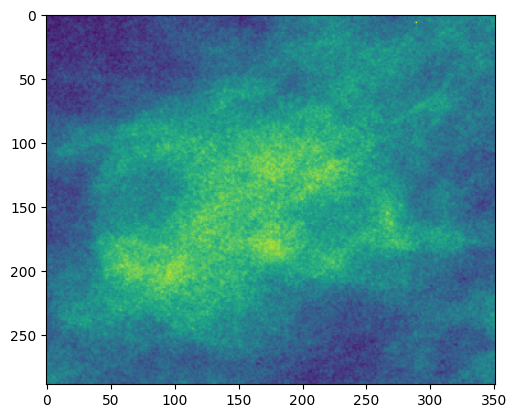

In [38]:
# Visualize the 1st instance of cropped_mammo_df using updated image path
for sample_image_path in cropped_mammo_df[0:1]['image_path']:
    sample_image = PIL.Image.open(sample_image_path)
    gray_img = sample_image.convert('L')
    plt.imshow(gray_img)

**Merge image dataframe with mass and calcification dataframes using 'series_uid' and 'study_uid'. Each image is mapped to its corresponding mass / calcification training or testing case using series_uid and study_uid.**

In [39]:
# Mass training + Cropped images data
mass_train_images_df = mass_train_df.merge(cropped_mammo_df, on=['series_uid', 'study_uid'], how='left')

In [40]:
# Mass testing + Cropped images data
mass_test_images_df = mass_test_df.merge(cropped_mammo_df, on=['series_uid', 'study_uid'], how='left')

In [41]:
# Calcification training + Cropped images data
calc_train_images_df = calc_train_df.merge(cropped_mammo_df, on=['series_uid', 'study_uid'], how='left')

In [42]:
# Calcification testing + Cropped images data
calc_test_images_df = calc_test_df.merge(cropped_mammo_df, on=['series_uid', 'study_uid'], how='left')

In [43]:
print("Mass Training: ", len(mass_train_images_df), ", Unique Series UID: ", mass_train_images_df['series_uid'].nunique())
print("Mass Testing: ", len(mass_test_images_df), ", Unique Series UID: ", mass_test_images_df['series_uid'].nunique())
print("Calc Training: ", len(calc_train_images_df), ", Unique Series UID: ", calc_train_images_df['series_uid'].nunique())
print("Calc Testing: ", len(calc_test_images_df), ", Unique Series UID: ", calc_train_images_df['series_uid'].nunique())

Mass Training:  1318 , Unique Series UID:  1318
Mass Testing:  378 , Unique Series UID:  378
Calc Training:  1546 , Unique Series UID:  1546
Calc Testing:  326 , Unique Series UID:  1546


In [44]:
# Mass training and testing data merged with cropped image data
print(mass_train_images_df.info())
print(mass_test_images_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  1318 non-null   object
 1   image view  1318 non-null   object
 2   pathology   1318 non-null   object
 3   series_uid  1318 non-null   object
 4   study_uid   1318 non-null   object
 5   image_path  1318 non-null   object
dtypes: object(6)
memory usage: 61.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378 entries, 0 to 377
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  378 non-null    object
 1   image view  378 non-null    object
 2   pathology   378 non-null    object
 3   series_uid  378 non-null    object
 4   study_uid   378 non-null    object
 5   image_path  378 non-null    object
dtypes: object(6)
memory usage: 17.8+ KB
None


In [45]:
# Calcification training and testing data merged with cropped image data
print(calc_train_images_df.info())
print(calc_test_images_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  1546 non-null   object
 1   image view  1546 non-null   object
 2   pathology   1546 non-null   object
 3   series_uid  1546 non-null   object
 4   study_uid   1546 non-null   object
 5   image_path  1544 non-null   object
dtypes: object(6)
memory usage: 72.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   patient_id  326 non-null    object
 1   image view  326 non-null    object
 2   pathology   326 non-null    object
 3   series_uid  326 non-null    object
 4   study_uid   326 non-null    object
 5   image_path  326 non-null    object
dtypes: object(6)
memory usage: 15.4+ KB
None


In [46]:
# Verification of NULL values in all merged dataframes
print(mass_train_images_df.isna().sum())
print(mass_test_images_df.isna().sum())
print(calc_train_images_df.isna().sum())
print(calc_test_images_df.isna().sum())

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
image_path    0
dtype: int64
patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
image_path    0
dtype: int64
patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
image_path    2
dtype: int64
patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
image_path    0
dtype: int64


**Drop NULL values from calc_train_images_df**

In [47]:
# Drop NULL image path cases in merged calcification training data merged with image data
calc_train_images_df = calc_train_images_df.dropna(subset=['image_path'])

In [48]:
calc_train_images_df.isna().sum()

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
image_path    0
dtype: int64

**Concatenate mass and calcification training dataframes into one train_df dataframe**

In [49]:
# Train DF = Mass Train DF + Calcification Train DF (merged with image data)
train_df = pd.concat([mass_train_images_df, calc_train_images_df], ignore_index=True)

**Concatenate mass and calcification testing dataframes into one test_df dataframe**

In [50]:
# Test DF = Mass Test DF + Calcification Test DF (merged with image data)
test_df = pd.concat([mass_test_images_df, calc_test_images_df], ignore_index=True)

* train_df: Comprises all mass and calcification training data with corresponding image paths of cropped mammograms.
* test_df: Comprises all mass and calcification testing data with corresponding image paths of cropped mammograms.

In [51]:
train_df.shape

(2862, 6)

In [52]:
test_df.shape

(704, 6)

In [53]:
train_df.isna().sum()

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
image_path    0
dtype: int64

In [54]:
test_df.isna().sum()

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
image_path    0
dtype: int64

In [55]:
test_df = test_df.dropna(subset=['image_path'])

In [56]:
test_df.shape

(704, 6)

In [57]:
test_df.isna().sum()

patient_id    0
image view    0
pathology     0
series_uid    0
study_uid     0
image_path    0
dtype: int64

**Pathology label-encoding in train_df and test_df**

In [58]:
train_df['pathology'].value_counts()

pathology
MALIGNANT                  1180
BENIGN                     1105
BENIGN_WITHOUT_CALLBACK     577
Name: count, dtype: int64

In [59]:
test_df['pathology'].value_counts()

pathology
BENIGN                     324
MALIGNANT                  276
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64

In [60]:
train_df['pathology'] = train_df['pathology'].replace('BENIGN_WITHOUT_CALLBACK', 'BENIGN')

In [61]:
train_df['pathology'].value_counts()

pathology
BENIGN       1682
MALIGNANT    1180
Name: count, dtype: int64

In [62]:
test_df['pathology'] = test_df['pathology'].replace('BENIGN_WITHOUT_CALLBACK', 'BENIGN')

In [63]:
test_df['pathology'].value_counts()

pathology
BENIGN       428
MALIGNANT    276
Name: count, dtype: int64

**Verify overlapping patients in train_df and test_df**

In [64]:
# Training patient cases
train_patients = set(train_df['patient_id'])

# Testing patient cases
test_patients = set(test_df['patient_id'])

# Overlap
overlapping_patients = train_patients & test_patients
print("Overlapping Pateints:", overlapping_patients)

Overlapping Pateints: {'P_01635', 'P_00882', 'P_01803', 'P_00510', 'P_01365', 'P_01605', 'P_00495', 'P_01566', 'P_00041', 'P_00924', 'P_01179', 'P_00159', 'P_01237', 'P_01741', 'P_00723', 'P_01307', 'P_01621', 'P_00016', 'P_01467', 'P_00591', 'P_01883', 'P_01108', 'P_00969', 'P_01152', 'P_00394', 'P_00652', 'P_00753', 'P_00601', 'P_00678', 'P_00906', 'P_00639'}


There are overlapping patients in train_df and test_df. This may result in data leakage during training and testing. Therefore, patient_id based data split must be performed.

**Patient ID based Dataset Split**

Concatenate train_df and test_df to create a combined data_df dataframe.

In [65]:
# Data DF = Train DF + Test DF
data_df = pd.concat([train_df, test_df], ignore_index=True)
data_df.shape

(3566, 6)

In [66]:
# Function to verify that an image at a given 'image_path' exists
def verify_image_exists(image_path):
    return os.path.exists(image_path)

In [67]:
# Cleaned dataframe with all image paths that actually exist
cleaned_data_df = data_df[data_df['image_path'].apply(verify_image_exists)] 

In [68]:
# Verification of existing image paths in the original Data DF
print(data_df.shape)
print(cleaned_data_df.shape)

(3566, 6)
(3566, 6)


In [69]:
# Extract all Unique patients from the combined data_df dataframe
unique_patients = data_df['patient_id'].unique()
unique_patients

array(['P_00001', 'P_00004', 'P_00009', ..., 'P_02464', 'P_02498',
       'P_02501'], shape=(1566,), dtype=object)

In [70]:
# Train-test split on unique patients with 20% patients for testing
train_val_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

In [71]:
print("Training and Validation patients: ", len(train_val_patients))
print("Testing patients: ", len(test_patients))

Training and Validation patients:  1252
Testing patients:  314


In [72]:
# Train-test split on 'training and validation patients' with 20% patients for validation
train_patients, val_patients = train_test_split(train_val_patients, test_size=0.2, random_state=42)

In [73]:
print("Training patients: ", len(train_patients))
print("Validation patients: ", len(val_patients))

Training patients:  1001
Validation patients:  251


In [74]:
# Combine all cases of training patients in new_train_df
new_train_df = data_df[data_df['patient_id'].isin(train_patients)]
new_train_df.shape

(2275, 6)

In [75]:
# Combine all cases of validation patients in new_val_df
new_val_df = data_df[data_df['patient_id'].isin(val_patients)]
new_val_df.shape

(587, 6)

In [76]:
# Combine all cases of testing patients in new_test_df
new_test_df = data_df[data_df['patient_id'].isin(test_patients)]
new_test_df.shape

(704, 6)

**Verify overlapping patients in new training, validation and testing datasets**

In [77]:
# Check for overlapping patients in Training and Testing data
train_p = set(new_train_df['patient_id'])
test_p = set(new_test_df['patient_id'])

overlaps1 = train_p & test_p
print("Overlaping Pateints Training and Testing:", overlaps1)

# Check for overlapping patients in Training and Validation data
val_p = set(new_val_df['patient_id'])
overlaps2 = train_p & val_p
print("Overlapping Patients Training and Validation:", overlaps2)

# Check for overlapping patients in Validation and Testing data
overlaps3 = val_p & test_p
print("Overlapping Patients Validation and Testing: ", overlaps3)

Overlaping Pateints Training and Testing: set()
Overlapping Patients Training and Validation: set()
Overlapping Patients Validation and Testing:  set()


No overlapping patients in training, validation and testing dataframes.

**Testing to store images in their respective dataset folders based on new dataset split**

**TESTING START**

In [78]:
output = Path('/kaggle/working/output')
output.mkdir(exist_ok=True)

In [79]:
sample = []
for row in new_train_df.head(5).itertuples():
    sample.append(row.image_path)

In [80]:
sample

[PosixPath('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg'),
 PosixPath('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/1-289.jpg'),
 PosixPath('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/2-295.jpg'),
 PosixPath('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/2-244.jpg'),
 PosixPath('/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/1-182.jpg')]

In [81]:
for i in range(5):
    print(root_path)
    print(sample[i])
    print("Relative: ", sample[i].relative_to(root_path))

/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg
Relative:  jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/1-289.jpg
Relative:  jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/1-289.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/2-295.jpg
Relative:  jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/2-295.jpg
/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
/kag

In [82]:
for i in range(5):
    relative_path = sample[i].relative_to(root_path)
    destination_path = output / relative_path
    destination_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(sample[i], destination_path)

**TESTING END**

**Store training, validation and testing images in their respective image folders in the output directory**

In [83]:
# Training dataset directory
train_dataset = Path('/kaggle/working/train_dataset')
train_dataset.mkdir(exist_ok=True)

# Validation dataset directory
val_dataset = Path('/kaggle/working/val_dataset')
val_dataset.mkdir(exist_ok=True)

# Tetsing dataset directory
test_dataset = Path('/kaggle/working/test_dataset')
test_dataset.mkdir(exist_ok=True)

In [84]:
# Copy images from original image folder to training directory using new_train_df image_path
for train_image_path in new_train_df['image_path']:
    relative_path = train_image_path.relative_to(root_path)
    destination_path = train_dataset / relative_path
    destination_path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(train_image_path, destination_path)

In [85]:
# Copy images from original image folder to validation directory using new_val_df image_path
for val_image_path in new_val_df['image_path']:
    relative_path_v = val_image_path.relative_to(root_path)
    destination_path_v = val_dataset / relative_path_v
    destination_path_v.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(val_image_path, destination_path_v)

In [86]:
# Copy images from original image folder to testing directory using new_test_df image_path
for test_image_path in new_test_df['image_path']:
    relative_path_t = test_image_path.relative_to(root_path)
    destination_path_t = test_dataset / relative_path_t
    destination_path_t.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(test_image_path, destination_path_t)

In [87]:
# ZIP for Training Image Dataset
shutil.make_archive('/kaggle/working/train_dataset', 'zip', '/kaggle/working/train_dataset')
print("Train ZIP generated")

Train ZIP generated


In [88]:
# ZIP for Validation Image Dataset
shutil.make_archive('/kaggle/working/val_dataset', 'zip', '/kaggle/working/val_dataset')
print("Validation ZIP generated")

Validation ZIP generated


In [89]:
# ZIP for Testing Image Dataset
shutil.make_archive('/kaggle/working/test_dataset', 'zip', '/kaggle/working/test_dataset')
print("Test ZIP generated")

Test ZIP generated


**Store new_train_df, new_val_df and new_test_df as CSV metadata files in output directory**

In [90]:
# Training metadata CSV
new_train_df.to_csv('train_data.csv', index=False)

In [91]:
# Validation metadata CSV
new_val_df.to_csv('val_data.csv', index=False)

In [92]:
# Testing metadata CSV
new_test_df.to_csv('test_data.csv', index=False)